In [3]:
import pandas as pd
df=pd.read_csv("sessions_summary.csv")
print(df.describe())

       speed_score  vibration_score  pause_ratio  smoothness_score  \
count   126.000000       126.000000   126.000000        126.000000   
mean   1509.858335       896.974221     0.288294          1.861173   
std     613.315799       439.449809     0.232015          0.749117   
min     276.589449        30.232787     0.010824          1.223820   
25%    1069.631544       549.335494     0.063928          1.531337   
50%    1486.744096       850.915509     0.213988          1.721227   
75%    1770.452580      1122.571261     0.507050          2.027438   
max    5024.139627      2843.395303     0.727578          9.148658   

          gyro_std      gyro_max    gyro_range   jerk_mean      jerk_max  \
count   126.000000    126.000000    126.000000  126.000000    126.000000   
mean   2409.015457  18556.863770  18459.025389  248.956549   5963.653279   
std    1208.953615   7944.353990   7929.918008  121.819247   3595.501209   
min      45.855645    307.645900    305.913850   23.537276    283

In [4]:
#type distribution
print(df['label'].value_counts())

label
perfect    43
medium     42
bad        41
Name: count, dtype: int64


In [13]:
import pandas as pd

# حمّلي الداتا
df = pd.read_csv("sessions_summary.csv")

# نشوف قبل الحذف
print("قبل الحذف:")
print(df["label"].value_counts())

# شرط الحذف
condition = (df["label"] == "bad") & (df["smoothness_score"] > 1.66)

# عدد اللي راح يتحذف
print("عدد bad اللي smoothness > 1.66:", condition.sum())

# حذف
df = df[~condition]

# حفظ
df.to_csv("sessions_summary.csv", index=False)

print("\nبعد الحذف:")
print(df["label"].value_counts())


قبل الحذف:
label
perfect    43
medium     42
bad        42
Name: count, dtype: int64
عدد bad اللي smoothness > 1.66: 0

بعد الحذف:
label
perfect    43
medium     42
bad        42
Name: count, dtype: int64


In [ ]:
import pandas as pd

CSV_PATH = "sessions_summary.csv"

# 1️⃣ قرا CSV
df = pd.read_csv(CSV_PATH)

# 2️⃣ شوف الأعمدة
print("Columns in CSV:", df.columns.tolist())

# 3️⃣ شوف آخر row و features فيه
last_row = df.iloc[-1]
print("\nLast row features:")
for col in df.columns:
    if col not in ["session_id", "label"]:
        print(f"{col}: {last_row[col]}")


Columns in CSV: ['session_id', 'label', 'speed_score', 'vibration_score', 'pause_ratio', 'smoothness_score', 'gyro_std', 'gyro_max', 'gyro_range', 'jerk_mean', 'jerk_max', 'energy', 'writer_id', 'text_id']

Last row features:
speed_score: 5024.139627187337
vibration_score: 2673.103093703284
pause_ratio: 0.4550748752079867
smoothness_score: 1.8795158470103903
gyro_std: 7139.496214046626
gyro_max: 41308.89572477096
gyro_range: 41027.76586154045
jerk_mean: 758.9346135561365
jerk_max: 20533.007148601133
energy: 76214385.18386023
writer_id: p01
text_id: word01


: 

In [ ]:
import pandas as pd

# حمّلي الداتا
df = pd.read_csv("sessions_summary.csv")

# نشوف قبل الحذف
print("قبل الحذف:")
print(df["label"].value_counts())

# شرط الحذف
condition = (df["label"] == "bad") & (df["smoothness_score"] > 1.)

# عدد اللي راح يتحذف
print("عدد bad اللي smoothness > 1.94:", condition.sum())

# حذف
df = df[~condition]

# حفظ
df.to_csv("sessions_summary.csv", index=False)

print("\nبعد الحذف:")
print(df["label"].value_counts())


قبل الحذف:
label
perfect    41
medium     41
bad        21
Name: count, dtype: int64
عدد medium اللي smoothness > 1.94: 0

بعد الحذف:
label
perfect    41
medium     41
bad        21
Name: count, dtype: int64


In [17]:
import pandas as pd

# نقرى الفichier
df = pd.read_csv("sessions_summary.csv")

# نحذف آخر سطر
df = df.iloc[:-1]

# نرجع نكتب الملف
df.to_csv("sessions_summary.csv", index=False)


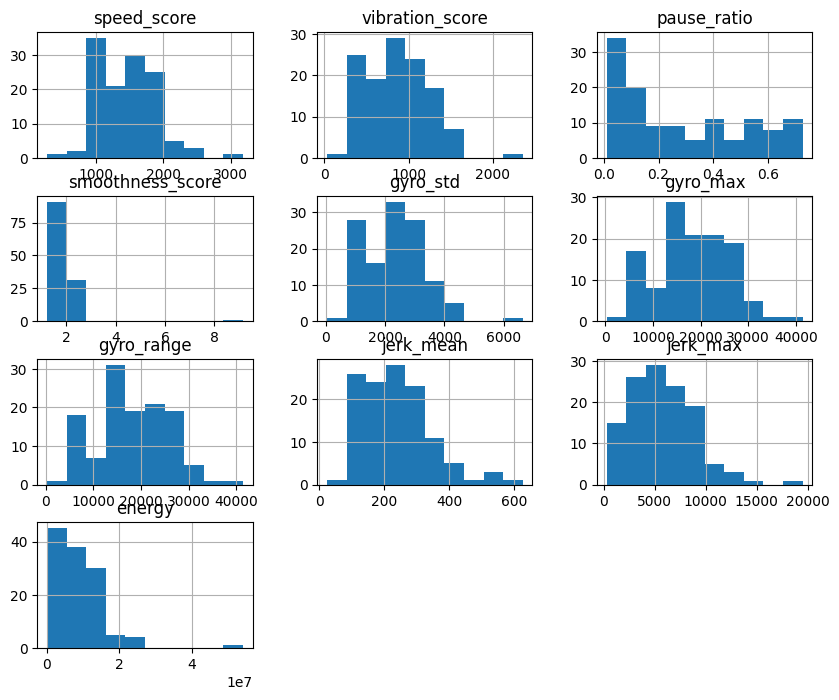

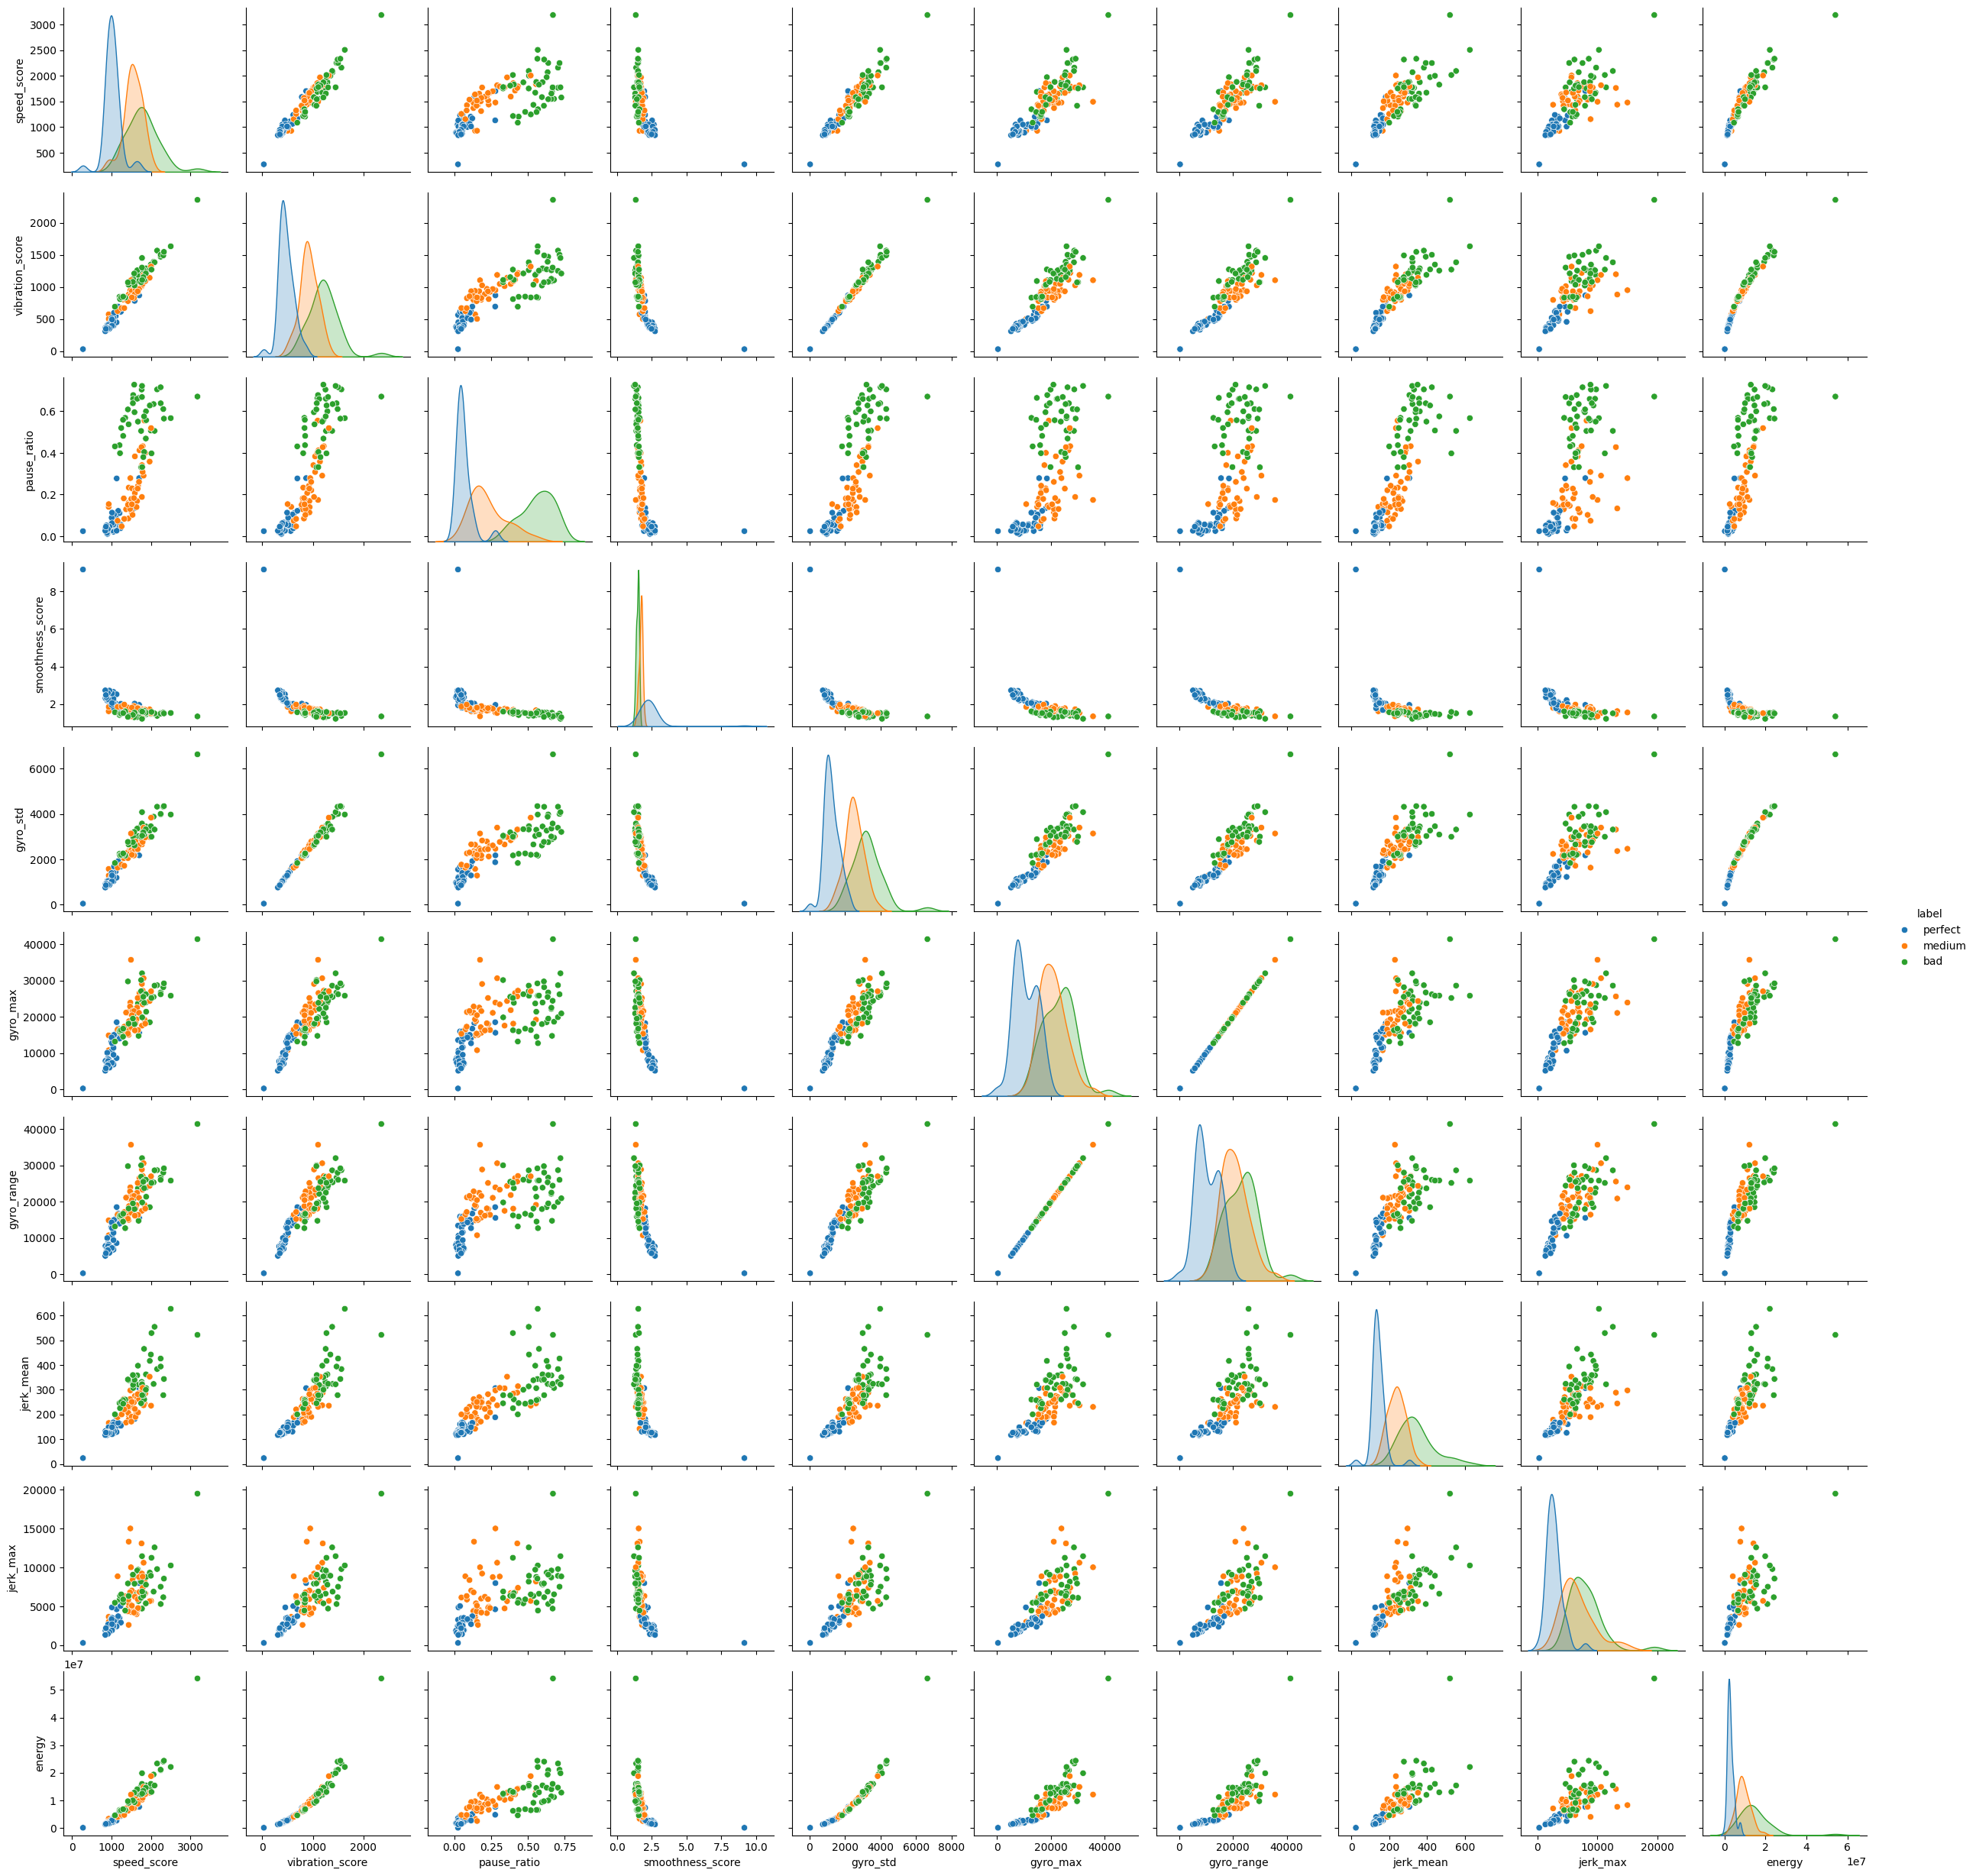

In [ ]:
#histogram

import seaborn as sns
import matplotlib.pyplot as plt

df.dropna().hist(figsize=(10,8))
plt.show()

sns.pairplot(df.dropna().drop_duplicates(),hue='label')
plt.show()

In [22]:
"""
smartpen_xgb_f1randsearch_cv.py

- Runs RandomizedSearchCV to tune XGBoost optimizing f1_macro
- Produces out-of-fold (cross_val_predict) predictions using the best estimator
- Prints focused results:
    * Accuracy (OOF)
    * Classification report (macro focus)
    * Confusion matrix
    * Top 10 feature importances
- Minimal other prints.

Usage:
    python smartpen_xgb_f1randsearch_cv.py

Requirements:
    pip install xgboost scikit-learn pandas numpy scipy
"""
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform

# ---------- CONFIG ----------
CSV_PATH = "sessions_summary.csv"
RANDOM_STATE = 42

N_ITER_SEARCH = 50     # number of random parameter settings to try
INNER_CV = 3           # inner CV for RandomizedSearchCV
OOF_FOLDS = 5          # folds for out-of-fold predictions

# ---------- LOAD & BASIC FILTER ----------
df = pd.read_csv(CSV_PATH)
df = df.dropna(how="all").reset_index(drop=True)
df = df[df["label"].isin(["bad", "medium", "perfect"])].reset_index(drop=True)

# ---------- SIMPLE COLUMN MAPPING (adjust if your CSV uses different names) ----------
def find_col(df_columns, candidates):
    for name in candidates:
        if name in df_columns:
            return name
    return None

candidates = {
    "speed": ["speed", "speed_score", "avg_speed", "mean_speed"],
    "vibration": ["vibration", "vibration_score", "vibe", "vibration_mean"],
    "pause_ratio": ["pause_ratio", "pause", "pause_ratio_score"],
    "smoothness": ["smoothness", "smoothness_score"],
    "gyro_std": ["gyro_std", "gyro_std_score", "gyro_std_dev"],
    "gyro_max": ["gyro_max", "gyro_max_score"],
    "gyro_range": ["gyro_range", "gyro_range_score"],
    "jerk_mean": ["jerk_mean", "jerk_avg", "jerk_mean_score"],
    "jerk_max": ["jerk_max", "jerk_peak"],
    "energy": ["energy", "energy_sum", "signal_energy"]
}

col_map = {logical: find_col(df.columns, cand) for logical, cand in candidates.items()}

# ---------- BUILD FEATURE DATAFRAME ----------
X_df = pd.DataFrame(index=df.index)
def safe_col(name):
    return col_map.get(name)

for logical in ["speed", "vibration", "pause_ratio", "smoothness", "gyro_std", "gyro_max",
                "gyro_range", "jerk_mean", "jerk_max", "energy"]:
    col = safe_col(logical)
    if col is not None:
        X_df[logical] = df[col]

# Derived features if inputs available
if safe_col("energy") is not None and safe_col("speed") is not None:
    X_df["gyro_energy_ratio"] = df[safe_col("energy")] / (df[safe_col("speed")] + 1)
if safe_col("jerk_mean") is not None and safe_col("speed") is not None:
    X_df["jerk_speed_ratio"] = df[safe_col("jerk_mean")] / (df[safe_col("speed")] + 1)
if safe_col("vibration") is not None and safe_col("gyro_std") is not None:
    X_df["stability_score"] = 1.0 / (df[safe_col("vibration")] + df[safe_col("gyro_std")] + 1.0)
if safe_col("smoothness") is not None and safe_col("pause_ratio") is not None:
    X_df["control_score"] = df[safe_col("smoothness")] / (df[safe_col("pause_ratio")] + 0.01)
if safe_col("gyro_max") is not None and safe_col("gyro_std") is not None:
    X_df["peak_ratio"] = df[safe_col("gyro_max")] / (df[safe_col("gyro_std")] + 1)

X_df = X_df.loc[:, X_df.notna().any(axis=0)]
if X_df.shape[1] < 3:
    raise RuntimeError("Too few features available to train a model. Check your CSV columns and mapping.")
X_df = X_df.fillna(X_df.median())

# ---------- PREPARE X, y ----------
label_map = {"bad": 0, "medium": 1, "perfect": 2}
y = df["label"].map(label_map).values
feature_names = list(X_df.columns)

# Log-transform highly skewed columns (optional but helpful)
skews = X_df.skew().abs()
for c in skews[skews > 1.0].index:
    if (X_df[c] > 0).all():
        X_df[c] = np.log1p(X_df[c])

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)

# ---------- XGBOOST + RANDOMIZED SEARCH (optimize f1_macro) ----------
xgb_base = XGBClassifier(
    objective="multi:softprob",
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

param_dist = {
    "n_estimators": [100, 200, 400, 600],
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5),
    "gamma": uniform(0.0, 0.5),
    "min_child_weight": randint(1, 8),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

inner_cv = StratifiedKFold(n_splits=INNER_CV, shuffle=True, random_state=RANDOM_STATE)

rand_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    scoring="f1_macro",           # optimize macro F1 as requested
    cv=inner_cv,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1,
    refit=True,
)

# Run search
rand_search.fit(X, y)
best = rand_search.best_estimator_

# ---------- OUT-OF-FOLD PREDICTIONS USING BEST ESTIMATOR ----------
oof_cv = StratifiedKFold(n_splits=OOF_FOLDS, shuffle=True, random_state=RANDOM_STATE)
y_pred_oof = cross_val_predict(best, X, y, cv=oof_cv, method="predict", n_jobs=-1)

# ---------- FOCUSED OUTPUTS ----------
acc = accuracy_score(y, y_pred_oof)
print("\n===== CROSS-VALIDATED (OUT-OF-FOLD) RESULTS - Best XGBoost (f1_macro tuned) =====")
print("Accuracy: {:.2f}%".format(acc * 100))
print("\nClassification Report:")
print(classification_report(y, y_pred_oof, target_names=["bad", "medium", "perfect"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_oof))

# Top feature importances
try:
    importances = best.feature_importances_
    fi = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
    topk = fi[:10]
    print("\nTop features (feature, importance):")
    for fname, imp in topk:
        print(f"{fname}: {imp:.4f}")
except Exception:
    pass

# Optionally print best params summary (concise)
print("\nBest params (concise):")
bp = rand_search.best_params_
# show only a subset of params for readability
show_keys = ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "gamma", "min_child_weight", "reg_alpha", "reg_lambda"]
print({k: bp[k] for k in bp if k in show_keys})

Fitting 3 folds for each of 50 candidates, totalling 150 fits

===== CROSS-VALIDATED (OUT-OF-FOLD) RESULTS - Best XGBoost (f1_macro tuned) =====
Accuracy: 85.71%

Classification Report:
              precision    recall  f1-score   support

         bad       0.88      0.90      0.89        41
      medium       0.77      0.81      0.79        42
     perfect       0.93      0.86      0.89        43

    accuracy                           0.86       126
   macro avg       0.86      0.86      0.86       126
weighted avg       0.86      0.86      0.86       126


Confusion Matrix:
[[37  4  0]
 [ 5 34  3]
 [ 0  6 37]]

Top features (feature, importance):
pause_ratio: 0.2188
smoothness: 0.1494
control_score: 0.1164
jerk_mean: 0.0924
speed: 0.0741
gyro_energy_ratio: 0.0504
gyro_max: 0.0501
vibration: 0.0419
energy: 0.0385
gyro_range: 0.0304

Best params (concise):
{'colsample_bytree': np.float64(0.8803925243084487), 'gamma': np.float64(0.2806385987847481), 'learning_rate': np.float64(0.1564

In [21]:
"""
smartpen_xgb_randsearch_cv.py

- Runs RandomizedSearchCV to tune XGBoost on your feature set
- Produces cross-validated (out-of-fold) predictions using the best estimator
- Prints the focused results you asked for:
    * Accuracy (CV / out-of-fold)
    * Classification report
    * Confusion matrix
    * Top 10 feature importances

Usage:
    python smartpen_xgb_randsearch_cv.py

Notes:
- Adjust CSV_PATH or parameter search space as needed.
- Requires: xgboost, scikit-learn, pandas, numpy
"""
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict,
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform

# ---------- CONFIG ----------
CSV_PATH = "sessions_summary.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.3

N_ITER_SEARCH = 40     # number of random parameter settings to try
INNER_CV = 3           # inner CV for RandomizedSearchCV
OUTER_CV_FOR_PRED = 5  # folds for final out-of-fold predictions

# ---------- LOAD & BASIC FILTER ----------
df = pd.read_csv(CSV_PATH)
df = df.dropna(how="all").reset_index(drop=True)
df = df[df["label"].isin(["bad", "medium", "perfect"])].reset_index(drop=True)

# ---------- COLUMN MAPPING (simple candidates used previously) ----------
def find_col(df_columns, candidates):
    for name in candidates:
        if name in df_columns:
            return name
    return None

candidates = {
    "speed": ["speed", "speed_score", "avg_speed", "mean_speed"],
    "vibration": ["vibration", "vibration_score", "vibe", "vibration_mean"],
    "pause_ratio": ["pause_ratio", "pause", "pause_ratio_score"],
    "smoothness": ["smoothness", "smoothness_score"],
    "gyro_std": ["gyro_std", "gyro_std_score", "gyro_std_dev"],
    "gyro_max": ["gyro_max", "gyro_max_score"],
    "gyro_range": ["gyro_range", "gyro_range_score"],
    "jerk_mean": ["jerk_mean", "jerk_avg", "jerk_mean_score"],
    "jerk_max": ["jerk_max", "jerk_peak"],
    "energy": ["energy", "energy_sum", "signal_energy"]
}

col_map = {logical: find_col(df.columns, cand) for logical, cand in candidates.items()}

# ---------- BUILD FEATURE DATAFRAME (same engineered features as before) ----------
X_df = pd.DataFrame(index=df.index)
def safe_col(name):
    return col_map.get(name)

for logical in ["speed", "vibration", "pause_ratio", "smoothness", "gyro_std", "gyro_max",
                "gyro_range", "jerk_mean", "jerk_max", "energy"]:
    col = safe_col(logical)
    if col is not None:
        X_df[logical] = df[col]

if safe_col("energy") is not None and safe_col("speed") is not None:
    X_df["gyro_energy_ratio"] = df[safe_col("energy")] / (df[safe_col("speed")] + 1)
if safe_col("jerk_mean") is not None and safe_col("speed") is not None:
    X_df["jerk_speed_ratio"] = df[safe_col("jerk_mean")] / (df[safe_col("speed")] + 1)
if safe_col("vibration") is not None and safe_col("gyro_std") is not None:
    X_df["stability_score"] = 1.0 / (df[safe_col("vibration")] + df[safe_col("gyro_std")] + 1.0)
if safe_col("smoothness") is not None and safe_col("pause_ratio") is not None:
    X_df["control_score"] = df[safe_col("smoothness")] / (df[safe_col("pause_ratio")] + 0.01)
if safe_col("gyro_max") is not None and safe_col("gyro_std") is not None:
    X_df["peak_ratio"] = df[safe_col("gyro_max")] / (df[safe_col("gyro_std")] + 1)

X_df = X_df.loc[:, X_df.notna().any(axis=0)]
if X_df.shape[1] < 3:
    raise RuntimeError("Too few features available to train a model. Check your CSV columns.")
X_df = X_df.fillna(X_df.median())

# ---------- PREPARE X, y ----------
label_map = {"bad": 0, "medium": 1, "perfect": 2}
y = df["label"].map(label_map).values
feature_names = list(X_df.columns)

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)

# ---------- XGBOOST + RANDOMIZED SEARCH SETUP ----------
xgb_base = XGBClassifier(
    objective="multi:softprob",
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

param_dist = {
    "n_estimators": [100, 200, 400, 600],
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.19),   # 0.01 - 0.20
    "subsample": uniform(0.6, 0.4),         # 0.6 - 1.0
    "colsample_bytree": uniform(0.5, 0.5),  # 0.5 - 1.0
    "gamma": uniform(0.0, 0.5),
    "min_child_weight": randint(1, 8),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

inner_cv = StratifiedKFold(n_splits=INNER_CV, shuffle=True, random_state=RANDOM_STATE)

rand_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    scoring="accuracy",
    cv=inner_cv,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1,
    refit=True,
)

# ---------- RUN RANDOMIZED SEARCH ----------
rand_search.fit(X, y)
best = rand_search.best_estimator_

# ---------- OUT-OF-FOLD PREDICTIONS USING BEST ESTIMATOR ----------
outer_cv = StratifiedKFold(n_splits=OUTER_CV_FOR_PRED, shuffle=True, random_state=RANDOM_STATE)
y_pred_oof = cross_val_predict(best, X, y, cv=outer_cv, method="predict", n_jobs=-1)

# ---------- FOCUSED OUTPUTS: Accuracy, Classification Report, Confusion Matrix ----------
acc = accuracy_score(y, y_pred_oof)
print("\n===== CROSS-VALIDATED (OUT-OF-FOLD) RESULTS - Best XGBoost =====")
print("Accuracy: {:.2f}%".format(acc * 100))
print("\nClassification Report:")
print(classification_report(y, y_pred_oof, target_names=["bad", "medium", "perfect"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_oof))

# ---------- TOP FEATURE IMPORTANCES (brief) ----------
try:
    importances = best.feature_importances_
    fi = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
    topk = fi[:10]
    print("\nTop features (feature, importance):")
    for fname, imp in topk:
        print(f"{fname}: {imp:.4f}")
except Exception:
    pass

# End

Fitting 3 folds for each of 40 candidates, totalling 120 fits

===== CROSS-VALIDATED (OUT-OF-FOLD) RESULTS - Best XGBoost =====
Accuracy: 85.71%

Classification Report:
              precision    recall  f1-score   support

         bad       0.88      0.90      0.89        41
      medium       0.77      0.81      0.79        42
     perfect       0.93      0.86      0.89        43

    accuracy                           0.86       126
   macro avg       0.86      0.86      0.86       126
weighted avg       0.86      0.86      0.86       126


Confusion Matrix:
[[37  4  0]
 [ 5 34  3]
 [ 0  6 37]]

Top features (feature, importance):
pause_ratio: 0.2188
smoothness: 0.1494
control_score: 0.1164
jerk_mean: 0.0924
speed: 0.0741
gyro_energy_ratio: 0.0504
gyro_max: 0.0501
vibration: 0.0419
energy: 0.0385
gyro_range: 0.0304
